In [13]:
using JuMP
using Gurobi
using Random
using Dualization
using Plots
using DataFrames
using CSV
import XLSX
import JSON

current_directory = @__DIR__
functions_directory = joinpath(current_directory, "functions")
data_dir = joinpath(current_directory, "data")
results_dir = joinpath(current_directory, "results")

# Include all the function files
# include(joinpath(functions_directory, "create_check_params.jl"))
# include(joinpath(functions_directory, "deterministic_equivalent.jl"))
# include(joinpath(functions_directory, "generate_cuts_from_dual.jl"))
include(joinpath(functions_directory, "load_model_starting_points.jl"))
# include(joinpath(functions_directory, "load_model_starting_points_OLD.jl"))
include(joinpath(functions_directory, "initialize_parameters.jl"))
include(joinpath(functions_directory, "process_scenario_data_n_selected_with_MVP.jl"))
include(joinpath(functions_directory, "process_scenario_data_n_selected.jl"))
# include(joinpath(functions_directory, "save_L_shaped_results.jl"))
include(joinpath(functions_directory, "select_random_scenarios.jl"))
include(joinpath(functions_directory, "create_vaccine_data.jl"))
# include(joinpath(functions_directory, "sub_problem.jl"))
# include(joinpath(functions_directory, "master_problem.jl"))
include(joinpath(functions_directory, "create_vaccine_data_MMR_only.jl"))

create_vaccine_data_MMR_only (generic function with 1 method)

In [3]:
A, V, A_v, P, P_v, V_a, V_p, P_a, A_p, capacity_category, vaccine_category, antigen_category = create_vaccine_data_MMR_only()

(["Measles", "Mumps", "Rubella"], ["M", "MR", "MMR"], Dict("MMR" => ["Measles", "Mumps", "Rubella"], "MR" => ["Measles", "Rubella"], "M" => ["Measles"]), ["Biological_E", "GSK", "PT_Bio", "Serum_Institute"], Dict("MMR" => ["Serum_Institute", "GSK"], "MR" => ["Serum_Institute", "Biological_E"], "M" => ["Serum_Institute", "PT_Bio"]), Dict("Measles" => ["MMR", "MR", "M"], "Mumps" => ["MMR"], "Rubella" => ["MMR", "MR"]), Dict("Serum_Institute" => ["MMR", "MR", "M"], "Biological_E" => ["MR"], "GSK" => ["MMR"], "PT_Bio" => ["M"]), Dict("Measles" => ["Serum_Institute", "GSK", "Biological_E", "PT_Bio"], "Mumps" => ["Serum_Institute", "GSK"], "Rubella" => ["Serum_Institute", "GSK", "Biological_E"]), Dict("Serum_Institute" => ["Measles", "Mumps", "Rubella"], "Biological_E" => ["Measles", "Rubella"], "GSK" => ["Measles", "Mumps", "Rubella"], "PT_Bio" => ["Measles"]), Dict("Medium" => ["Sanofi", "Pfizer", "Haffkine_Bio", "Bharat_Biotech", "Merck_Sharp", "PT_Bio", "LG_Chem", "BB_NCIPD"], "Small" =>

In [ ]:
starting_points_vect_F, starting_points_vect_I, starting_points_vect_S = load_model_starting_points(data_dir, 1, 1000, A, V)

In [5]:
T, T_initial, Δ, s_real, r, r_avg, r_producer_avg, g, h, l, f_profit, Γ, F_time_set, κ, L_lower_number, L_upper_number, delta, beta, zeta_vm, phi_vm_lower, phi_vm_upper, m_segments = initialize_parameters(data_dir, 1000, 1, 10, 5, P, V, P_v, V_p, 1)

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [1, 2, 3, 4, 5], Dict{Any, Any}("Serum_Institute" => 587114.0, "Biological_E" => 164886.0, "GSK" => 226763.0, "PT_Bio" => 45912.0), Dict{Any, Any}(("MMR", "Serum_Institute", 5) => 2.2953333333333332, ("M", "PT_Bio", 5) => 0.2675, ("M", "Serum_Institute", 8) => 0.436734375, ("MR", "Serum_Institute", 5) => 0.890625, ("MR", "Serum_Institute", 10) => 0.89083984375, ("MMR", "GSK", 8) => 4.47, ("MR", "Serum_Institute", 2) => 0.8925000000000001, ("MR", "Biological_E", 3) => 0.87, ("M", "PT_Bio", 4) => 0.265, ("MR", "Biological_E", 8) => 0.92121875…), Dict{Any, Any}(("MMR", 1) => 3.207, ("MMR", 2) => 3.303166666666667, ("MMR", 8) => 3.372729166666667, ("M", 6) => 0.35134375, ("MR", 4) => 0.917875, ("MR", 10) => 0.905447265625, ("M", 8) => 0.35164843749999997, ("MR", 6) => 0.9084062500000001, ("M", 9) => 0.35180078125, ("MMR", 9) => 3.3743854166666667…), Dict{Any, Any}("Serum_Institute" => 1.1832658854166667, "Biological_E" =

In [14]:
Scenarios_used, p_ω_test, p_ω_test_partial_2, Ω_test_partial_1, Ω_test_partial_2, partial_scenario, s_real_tilde, d_real_tilde, random_scenarios = process_scenario_data_n_selected(current_directory, data_dir, 3, 3, A, T, P, 1, 10, 5, 1, 1, 1, 1)

(Dict("Partial_1" => [4], "All" => [4, 5, 6, 7, 8, 9, 1, 2, 3], "Partial_2" => [5, 6, 7, 8, 9, 1, 2, 3]), Dict(5 => 0.021174243267633855, 4 => 0.0184294339551628, 6 => 0.016116892748786363, 7 => 0.0015552801502578839, 2 => 0.08077581690986248, 9 => 0.00037874697959647957, 8 => 0.0016600399531249953, 3 => 0.07567831390098767, 1 => 0.7842312321345873), Dict(5 => 0.02157179931846758, 6 => 0.01641949474272455, 7 => 0.0015844812426729189, 2 => 0.08229241962230226, 9 => 0.00038585812645402693, 8 => 0.0016912079585006286, 3 => 0.07709920867526376, 1 => 0.7989555303136142), [4], [5, 6, 7, 8, 9, 1, 2, 3], 4, Dict{Any, Any}(("GSK", 2, 5) => 226763.0, ("PT_Bio", 2, 7) => 45912.0, ("GSK", 6, 6) => 226763.0, ("Biological_E", 3, 3) => 164886.0, ("Biological_E", 8, 1) => 164886.0, ("Biological_E", 5, 9) => 164886.0, ("Biological_E", 7, 9) => 164886.0, ("GSK", 7, 8) => 226763.0, ("GSK", 8, 4) => 226763.0, ("Biological_E", 7, 8) => 164886.0…), Dict{Any, Any}(("Rubella", 8, 7) => 670139.0, ("Mumps", 5, 

In [11]:
s_real_tilde

Dict{Any, Any} with 1400 entries:
  ("GSK", 5, 21)              => 226763.0
  ("Biological_E", 1, 14)     => 164886.0
  ("PT_Bio", 2, 7)            => 45912.0
  ("Serum_Institute", 10, 29) => 587114.0
  ("PT_Bio", 2, 26)           => 45912.0
  ("GSK", 1, 31)              => 226763.0
  ("Biological_E", 10, 10)    => 164886.0
  ("GSK", 7, 28)              => 225375.0
  ("Biological_E", 4, 13)     => 92336.0
  ("Biological_E", 10, 33)    => 164886.0
  ("GSK", 6, 28)              => 226763.0
  ("Serum_Institute", 4, 10)  => 587114.0
  ("Biological_E", 1, 19)     => 164886.0
  ("Biological_E", 10, 14)    => 164886.0
  ("Biological_E", 6, 7)      => 164886.0
  ("Serum_Institute", 4, 6)   => 587114.0
  ("GSK", 7, 5)               => 226763.0
  ("GSK", 2, 32)              => 226381.0
  ("Biological_E", 8, 10)     => 164886.0
  ⋮                           => ⋮

In [ ]:
d_real_tilde[("Rubella",1,1)]

In [163]:
# single cut
new_updated_data = {
  "lb": [
    2730757.948266739, 2753437.5865218765, 2792268.1867326195, 2906969.860122906,
    2931288.238614109, 2931288.23861411, 2995526.625971041, 2995526.6259710426,
    3065745.9432598837, 3121966.982965835, 3121966.9829658368, 3172088.232226982,
    3177025.7166400556, 3263023.420567234, 3299296.2530680383, 3359486.5871076053,
    3359486.587107606, 3402579.323442435, 3415050.871614099, 3423188.782277356,
    3479072.9958543237, 3494130.1898825224, 3517117.7253941665, 3517117.7253941675,
    3517117.725394169, 3533389.881719587, 3541601.835673179, 3541601.835673181,
    3555629.8038226226, 3569681.7842955515, 3597622.7995006493, 3597622.799500652,
    3597622.7995006545, 3616247.855733963, 3616247.8557339655, 3638718.7604757356,
    3662598.681619752, 3662598.681619753, 3683238.9338268973, 3683238.9338269,
    3695603.9209258966, 3701902.2144393735, 3709434.3503316278, 3721369.974608314,
    3728882.9996074387, 3736039.0200911458, 3742955.4450065983, 3758161.944419313
  ],
  "ub": [
    1453052913.116875, 1453052913.116875, 1389797060.991853, 1389797060.991853,
    1389797060.991853, 1213812878.9341185, 1213812878.9341185, 1213812878.9341185,
    1213812878.9341185, 1213812878.9341185, 1213812878.9341185, 1127472274.010198,
    1014564047.2648522, 1014564047.2648522, 1014564047.2648522, 1014564047.2648522,
    1014564047.2648522, 827362442.0708812, 827362442.0708812, 827362442.0708812,
    827362442.0708812, 827362442.0708812, 827362442.0708812, 798299495.6727923,
    798299495.6727923, 798299495.6727923, 798299495.6727923, 798299495.6727923,
    798299495.6727923, 798299495.6727923, 798299495.6727923, 798299495.6727923,
    798299495.6727923, 798299495.6727923, 798299495.6727923, 754582465.8669627,
    754582465.8669627, 754582465.8669627, 754582465.8669627, 754582465.8669627,
    745272917.3403171, 725677411.7260152, 725677411.7260152, 725677411.7260152,
    718205353.8145057, 718205353.8145057, 697750965.5755394, 697750965.5755394
  ]
}


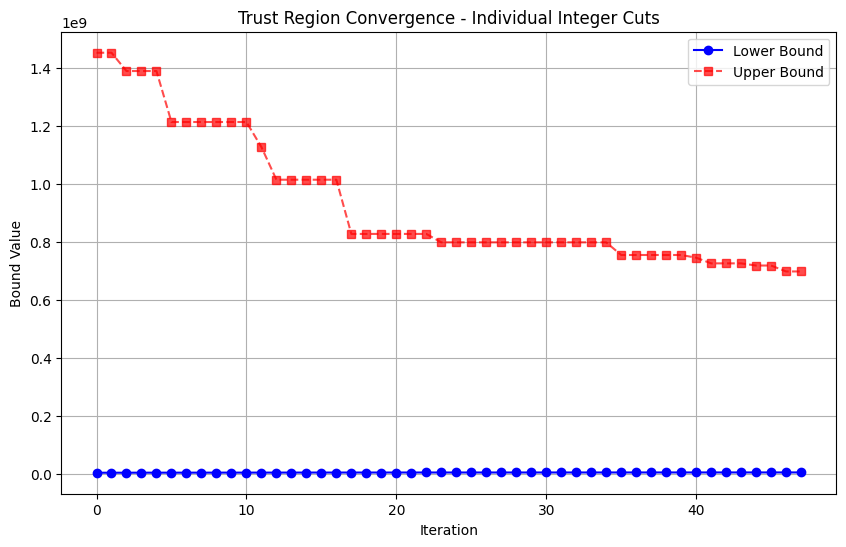

In [165]:
import matplotlib.pyplot as plt

# # Adjust the length of both lists to match the shorter one
# min_length = min(len(lower_bounds), len(upper_bounds))

# # Trim both lists to the same length
# lower_bounds = lower_bounds[:min_length]
# upper_bounds = upper_bounds[:min_length]
# iterations = list(range(min_length))

# Plot the adjusted lower and upper bounds
plt.figure(figsize=(10, 6))
# Plot lower and upper bounds
plt.plot(new_updated_data["lb"], label="Lower Bound", marker="o", linestyle="-", color="blue")
plt.plot(new_updated_data["ub"], label="Upper Bound", marker="s", linestyle="--", color="red", alpha=0.7)

# Labels and title
plt.xlabel("Iteration")
plt.ylabel("Bound Value")
plt.title("Trust Region Convergence - Aggreated Integer Cuts")
plt.legend()
plt.grid(True)
plt.savefig("UG_Trust_region_F_L_Y_Z_aggregated_cut.pdf")
# Show the plot
plt.show()


In [ ]:
            if iter2 >= 2
                println("Generating trust region cuts")
                # F variable
                try
                    unregister(Masterproblem, :trust_region_constr_all)
                catch e
                    println("No constraint: ", e)
                finally
                    trust_expr_F = sum(
                        F_bar[a, (t, tau)] == 1 ? (1 - Masterproblem[:F][a, (t, tau)]) :
                                                  Masterproblem[:F][a, (t, tau)]
                        for a in A, (t, tau) in F_time_set
                    )

                    trust_expr_Y = sum(
                            Y_bar[p, t] == 1 ? (1 - Masterproblem[:Y][p, t]) : Masterproblem[:Y][p, t]
                            for p in P, t in T
                        )

                    trust_expr_L = sum(
                        L_bar[p, t] == 1 ? (1 - Masterproblem[:L][p, t]) : Masterproblem[:L][p, t]
                        for p in P, t in T
                    )

                    trust_expr_Z = sum(
                            Z_bar[v, p, t, m] == 1 ? (1 - Masterproblem[:Z][v, p, t, m]) : Masterproblem[:Z][v, p, t, m]
                            for v in V, p in P_v[v], t in T, m in keys(m_segments)
                        )

                    trust_expr_all = trust_expr_F + trust_expr_Y + trust_expr_L + trust_expr_Z
                    @constraint(Masterproblem, trust_region_constr_all, trust_expr_all <= trust_delta_F)
                end
            end

In [ ]:
            # # add solution elimination constraints (Masterproblem, iter, Z_M, Z_M_prev) - create a function for this - MULTIPLE TRUST REGIONS FOR EACH BINARY
            # if iter2 == 1
            #     trust_delta_F = max_horizon_length * max_tender_length * length(A)/ 2
            #     trust_delta_Y = length(P) * length(T) / 2
            #     trust_delta_L = length(P) * length(T) / 2
            #     trust_delta_Z = length(V) * length(P) * length(T) * length(m_segments) /2
            # elseif iter2 >= 2
            #     if Z_M >= Z_M_prev
            #         trust_delta_F = ceil(1.3*trust_delta_F)
            #         trust_delta_Y = ceil(1.3*trust_delta_Y)
            #         trust_delta_L = ceil(1.3*trust_delta_L)
            #         trust_delta_Z = ceil(1.3*trust_delta_Z)
            #     else
            #         trust_delta_F = ceil(0.6*trust_delta_F)
            #         trust_delta_Y = ceil(0.6*trust_delta_Y)
            #         trust_delta_L = ceil(0.6*trust_delta_L)
            #         trust_delta_Z = ceil(0.6*trust_delta_Z)
            #     end
            # end

            # println("Current F trust region RHS: $trust_delta_F")
            # println("Current Y trust region RHS: $trust_delta_Y")
            # println("Current L trust region RHS: $trust_delta_L")
            # println("Current Z trust region RHS: $trust_delta_Z")

            # if iter2 >= 2
            #     println("Generating trust region cuts")
            #     # F variable
            #     try
            #         unregister(Masterproblem, :trust_region_constr_F)
            #     catch e
            #         println("No constraint: ", e)
            #     finally
            #         trust_expr = sum(
            #             F_bar[a, (t, tau)] == 1 ? (1 - Masterproblem[:F][a, (t, tau)]) :
            #                                       Masterproblem[:F][a, (t, tau)]
            #             for a in A, (t, tau) in F_time_set
            #         )
            #         @constraint(Masterproblem, trust_region_constr_F, trust_expr <= trust_delta_F)
            #     end

            #     # Y variable
            #     try
            #         unregister(Masterproblem, :trust_region_constr_Y)
            #     catch e
            #         println("No constraint: ", e)
            #     finally
            #         @constraint(Masterproblem, trust_region_constr_Y,
            #             sum(
            #                 Y_bar[p, t] == 1 ? (1 - Masterproblem[:Y][p, t]) : Masterproblem[:Y][p, t]
            #                 for p in P, t in T
            #             ) <= trust_delta_Y)
            #     end
                

            #     # L variable

            #     try
            #         unregister(Masterproblem, :trust_region_constr_L)
            #     catch e
            #         println("No constraint: ", e)
            #     finally
            #         @constraint(Masterproblem, trust_region_constr_L,
            #         sum(
            #             L_bar[p, t] == 1 ? (1 - Masterproblem[:L][p, t]) : Masterproblem[:L][p, t]
            #             for p in P, t in T
            #         ) <= trust_delta_L)
            #     end
            
            #     # # Z variable
            #     try
            #         unregister(Masterproblem, :trust_region_constr_Z)
            #     catch e
            #         println("No constraint: ", e)
            #     finally
            #         @constraint(Masterproblem, trust_region_constr_Z,
            #             sum(
            #                 Z_bar[v, p, t, m] == 1 ? (1 - Masterproblem[:Z][v, p, t, m]) : Masterproblem[:Z][v, p, t, m]
            #                 for v in V, p in P_v[v], t in T, m in keys(m_segments)
            #             ) <= trust_delta_Z)
            #     end
            # end #end iter generation of trust region cuts   